### Код для локального сервера

In [ ]:
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder
import torch
from torch import nn
import torch.functional as F
from torch.utils.data import DataLoader, Subset, random_split

from torchvision.transforms import InterpolationMode
from torchvision import models
from torchvision.datasets import VisionDataset
from torchvision.transforms import ToTensor, Resize, Normalize, Compose, RandomResizedCrop, ColorJitter, RandomHorizontalFlip, RandomPerspective, RandomRotation, InterpolationMode, RandomApply, GaussianBlur

import random
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from PIL import Image

from tqdm import tqdm
import re

import os
import requests

import warnings
warnings.filterwarnings("ignore")

In [ ]:
root_dir = "data"
img_dir = "images"
csv_path = "attr_no_noise.csv"

In [ ]:
def get_idx_row_from_image(img_name, data):
    (id, img_num) = img_name.split(".")[0].split("_")
    id = int(id)
    img_num = int(img_num)
    series = data[(data["ID"] == id) & (data["img_num"] == img_num)]
    idx = series.index[0]
    row = series.iloc[0]

    return (idx, row)

In [ ]:
class Attr_Positive(VisionDataset):
    def __init__(self, root_dir, img_dir, csv_path, transform=None):
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.csv_path = csv_path

        super().__init__(self.root_dir, transform=transform)

        self.transform = transform

        self.image_paths = []
        self.labels = []
        self.orig_indices = []

        self._build_dataset()

    def _build_dataset(self):
        data = pd.read_csv(os.path.join(self.root_dir, self.csv_path))
        for img_name in os.listdir(os.path.join(self.root_dir, self.img_dir)):
            #idx = int(img_name.split('.')[0]) // old

            idx, row = get_idx_row_from_image(img_name, data)

            if row.attr_val == 0:
                continue

            if row.attr_ind == 8:
                continue

            self.labels.append(row.attr_ind)
            self.orig_indices.append(idx)

            img_path = os.path.join(self.root_dir, self.img_dir, img_name)
            self.image_paths.append(img_path)

        print(f"Dataset loaded: {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image,

In [ ]:
default_transform = Compose(
    [Resize((384, 384)), ToTensor(), Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
)

ds = Attr_Positive(transform=default_transform, root_dir=root_dir, img_dir=img_dir, csv_path=csv_path)

Dataset loaded: 9651 images


In [ ]:
train_test_split = 0.9
train_val_split = 1.0
train_size = int(train_test_split * len(ds))
test_size = len(ds) - train_size
val_size = train_size - int(train_size * train_val_split)
train_size = int(train_size * train_val_split)

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(ds, [train_size, val_size, test_size], generator=generator)

#### Аугментации

In [ ]:
train_transform = Compose([
    RandomResizedCrop(
        size=(384, 384),
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1)
    ),
    RandomHorizontalFlip(p=0.5),

    ColorJitter(
        brightness=0.2,
        contrast=0.3,
        saturation=0.15,
        hue=0.05
    ),

    RandomApply([
        GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))
    ], p=0.2),

    RandomApply([
        RandomRotation(
            degrees=7,
            interpolation=InterpolationMode.BILINEAR
        )
    ], p=0.3),

    RandomApply([
        RandomPerspective(
            distortion_scale=0.15,
            p=1.0
        )
    ], p=0.2),

    ToTensor(),

    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

default_transform = Compose([
    Resize((384, 384)),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_ds.transform = train_transform

#### Модельки

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, do_val, weights=None):
    criterion = nn.CrossEntropyLoss()
    if weights is not None:
        criterion.weight = weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.999))

    history = {"train_loss": []}
    if do_val:
        history["val_acc"] = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        print("Training:")
        for x, y in tqdm(train_loader):
            x = x.to(device)
            y = y.to(device).long()

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train loss: {avg_loss:.4f}")

        if not do_val:
            continue

        model.eval()
        all_probs = []
        all_preds = []
        all_y = []

        print("Validation:")
        with torch.no_grad():
            for x, y in tqdm(val_loader):
                x = x.to(device)
                y = y.to(device).long()

                out = model(x)
                probs = torch.softmax(out, dim=1)
                preds = torch.argmax(probs, dim=1)

                all_probs.append(probs.cpu())
                all_preds.append(preds.cpu())
                all_y.append(y.cpu())

        all_probs = torch.cat(all_probs).numpy()
        all_preds = torch.cat(all_preds).numpy()
        all_y = torch.cat(all_y).numpy()

        val_acc = accuracy_score(all_y, all_preds)

        print(f"  Val acc: {val_acc:.4f}")

        history["val_acc"].append(val_acc)

    return history

In [ ]:
model = models.convnext_small(weights="ConvNeXt_Small_Weights.DEFAULT")

for p in model.parameters():
    p.requires_grad = False

model.classifier[2] = nn.Linear(model.classifier[2].in_features, 13, bias=True)

#### Треним

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
device

'cuda'

In [ ]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=4, lr=0.001, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 136/136 [02:31<00:00,  1.11s/it]


Epoch 1/4:
  Train loss: 1.6289
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:17<00:00,  1.08s/it]


  Val acc: 0.5166
  Val micro f1: 0.5166
  Val macro f1: 0.3817
  Val AUC (OvR, macro): could not be computed (Number of classes in y_true not equal to the number of columns in 'y_score')
Training:


...

Epoch 3/4:
  Train loss: 1.2520
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:16<00:00,  1.06s/it]


  Val acc: 0.5518
  Val micro f1: 0.5518
  Val macro f1: 0.4724
  Val AUC (OvR, macro): could not be computed (Number of classes in y_true not equal to the number of columns in 'y_score')
Training:


 78%|██████████████████████████████████████████████████████████████▎                 | 106/136 [02:02<00:34,  1.15s/it]


KeyboardInterrupt: 

#### Тюним

батч поменьше

In [ ]:
for p in model.parameters():
    p.requires_grad = True

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

fine_tuning_hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=7, lr=0.00001, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 543/543 [05:59<00:00,  1.51it/s]


Epoch 1/7:
  Train loss: 1.1212
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:17<00:00,  1.10s/it]


  Val acc: 0.6056
  Val micro f1: 0.6056
  Val macro f1: 0.5732
  Val AUC (OvR, macro): could not be computed (Number of classes in y_true not equal to the number of columns in 'y_score')
Training:


  1%|█▏                                                                                | 8/543 [00:06<06:45,  1.32it/s]


KeyboardInterrupt: 

#### Тестим

100%|██████████████████████████████████████████████████████████████████████████████████| 31/31 [00:17<00:00,  1.79it/s]



  Test accuracy: 0.6035


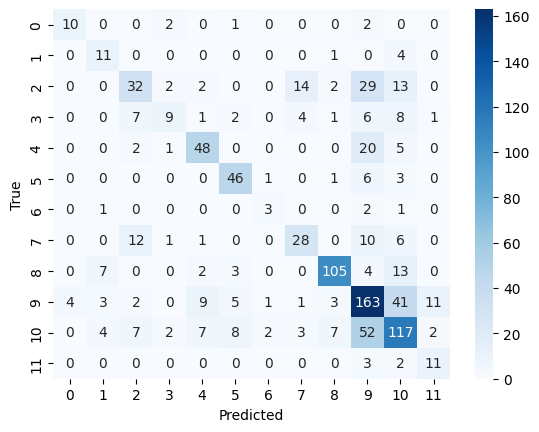

In [ ]:
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

model.eval()
all_preds = []
all_probs = []
all_y = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x, y = x.to(device), y.to(device).long()
        out = model(x)

        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_y.append(y.cpu())


all_probs = torch.cat(all_probs).numpy()
all_preds_top3 = np.argsort(all_probs, axis=1)[:,-3:]
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
conf_mat = confusion_matrix(all_y, all_preds)

print()
print(f"  Test accuracy: {test_acc:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
orig_ind = []
for i in test_ds.indices:
    orig_ind.append(ds.orig_indices[i])
data.iloc[orig_ind][["attr_ind", "attr"]].value_counts().sort_index()

attr_ind  attr                                                                                    
0.0       Наличие подтоплений                                                                          22
1.0       Наличие сухостойных деревьев (только деревья)                                                26
2.0       Нарушение содержания мест проведения работ по комплексному благоустройству                   80
3.0       Нарушение содержания мест проведения работ по ремонту инженерных сооружений                  26
4.0       Нарушение содержания объектов ЦОДД                                                           93
5.0       Нарушение содержания объектов гор.моста                                                      56
6.0       Нарушение содержания рекламных конструкций                                                    9
7.0       Нарушение содержания строительной площадки                                                   49
8.0       Нарушение содержания фасадов нежилых зданий



attr_ind  attr                                                                                    
0.0 |Наличие подтоплений                                                                          180 \
1.0 |Наличие сухостойных деревьев (только деревья)                                                236 \
2.0 |Нарушение содержания мест проведения работ по комплексному благоустройству                   745 \
3.0 |Нарушение содержания мест проведения работ по ремонту инженерных сооружений                  296 \
4.0 |Нарушение содержания объектов ЦОДД                                                           638 \
5.0 |Нарушение содержания объектов гор.моста                                                      496 \
6.0 |Нарушение содержания рекламных конструкций                                                    89 \
7.0 |Нарушение содержания строительной площадки                                                   525 \
8.0 |Нарушение содержания фасадов нежилых зданий и сооружений                                    5205 \
9.0 |Нарушение состояния фасада жилых зданий                                                      989 \
10. |Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс    2447 \
11. |Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д                                   1886 \
12. |Неудовлетворительное содержание ОЛХ                                                          146 \

In [ ]:
probs_argsorted = np.argsort(all_probs, axis=1)
print(f"total objects:  {all_probs.shape[0]}")
for i in range(1, 6):
    k = 0

    mask = ((probs_argsorted[:,-i:]) == all_y[:, None]).any(axis=1)

    for j in probs_argsorted[:,-i:]:
        if 8 in j: k += 1

    print(f"top {i} accuracy:   {np.where(mask)[0].shape[0] / all_probs.shape[0]}")

    print(k)

total objects:  1542
top 1 accuracy:   0.6783398184176395
670
top 2 accuracy:   0.8696498054474708
869
top 3 accuracy:   0.9286640726329443
999
top 4 accuracy:   0.9649805447470817
1135
top 5 accuracy:   0.9818417639429312
1271


In [ ]:
data = pd.read_csv("data/attr_classifier.csv")

In [ ]:
facade = Facade(transform=Resize((384, 384)), root_dir=root_dir, img_dir=img_dir, csv_path=csv_path, attr="Нарушение содержания объектов ЦОДД")

Dataset loaded: 1359 images


In [ ]:
k = 0
d = test_ds
for ind in range(len(ds)):
    if ind not in d.indices:
        continue
    if data.iloc[ds.orig_indices[ind]].attr_val == 0:
        k += 1
        #print(ind)
        #plt.imshow(facade[ind][0])
        #plt.show()

print()
print(len(d))
print(k)
print(k / len(d))


2136
594
0.27808988764044945


In [ ]:
def predict_image(model, image_path, transform, device, threshold=0.5):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image)

    image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():
        logits = model(image)
        prob = torch.sigmoid(logits).item()
        pred = int(prob > threshold)

    return {
        "probability": prob,
        "prediction": pred
    }

In [ ]:
d = test_ds
imgs = []
for ind in range(len(ds)):
    if ind not in d.indices:
        continue
    if data.iloc[ds.orig_indices[ind]].attr_val == 0:
        imgs.append((data.iloc[ds.orig_indices[ind]].ID, data.iloc[ds.orig_indices[ind]].img_num))

In [ ]:
preds = np.zeros(len(imgs))
for ind, i in enumerate(imgs):
    preds[ind] = predict_image(model, os.path.join(root_dir, img_dir, str(i[0]) + "_" + str(i[1]) + ".jpg"), default_transform, device, threshold=0.9)["probability"]
preds.mean()

0.3566743034699287

In [ ]:
model = models.convnext_small()
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 1, bias=True)
model.load_state_dict(torch.load("models/pure_classifier/convnext_s_2.pth", weights_only=True))
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device);

#### Сохранение

#### convnext_s_2.pth - 0.91 top 5

In [ ]:
torch.save(model.state_dict(), "models/pos_attr_classifier/convnext_s.pth")

In [ ]:
with open("fixed_test_sets/resident_facade.txt", "x") as f:
    for i in test_ds.indices:
        f.write(str(i) + "\n")

### Папки:
not_resident_facade

resident_facade

roads_bus_stops

sanitation_lighting

codd

## Классы (очищенный датасет)

! дисбаланс по меткам указан как 0/1

---

### Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс
3453 объектов, дисбаланс 0.22/0.78

thresh = 0.7

accuracy: 0.8613

balanced accuracy: 0.8413

auc: 0.8969

---

### Нарушение содержания фасадов нежилых зданий и сооружений:
6757 объектов, дисбаланс 0.15/0.85

thresh = 0.8

accuracy: 0.8195

balanced accuracy: 0.7729

auc: 0.8699

---

### Нарушение содержания объектов гор.мост
1064 объектов, дисбаланс 0.48/0.52


---
### Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д:
2803 объектов, дисбаланс 0.25/0.75

thresh = 0.9

accuracy: acc = 0.83

balanced accuracy: 0.83

auc: 0.8699

---
### Нарушение содержания строительной площадки
641 объектов, дисбаланс 0.10/0.90


---
### Нарушение содержания мест проведения работ по комплексному благоустройству
859 объектов, дисбаланс 0.04/0.96


---
### Нарушение содержания мест проведения работ по ремонту инженерных сооружений
960 объектов, дисбаланс 0.66/0.34


----
### Наличие подтоплений
739 объектов, дисбаланс 0.73/0.27


---
### Нарушение содержания объектов ЦОДД

1358 объектов, дисбаланс 0.46/0.54

thresh = 0.65

accuracy: 0.7721

balanced accuracy: 0.7713

auc: 0.8574

---
### Нарушение содержания рекламных конструкций
634 объектов, дисбаланс 0.85/0.15


---
### Нарушение состояния фасада жилых зданий
1648 объектов, дисбаланс 0.32/0.68

thresh = 0.4

accuracy: 0.9030

balanced accuracy: 0.8864

auc: 0.9522


---
### Наличие сухостойных деревьев (только деревья)
262 объектов, дисбаланс 0.00/1.00 (мда)


---
### Неудовлетворительное содержание ОЛХ
177 объектов (отлично), дисбаланс 0.07/0.93




Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс:    3453    0.78
Нарушение содержания фасадов нежилых зданий и сооружений:    6757    0.85
Нарушение содержания объектов гор.моста:    1064    0.52
Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д:    2803    0.75
Нарушение содержания строительной площадки:    641    0.90
Нарушение содержания мест проведения работ по комплексному благоустройству:    859    0.96
Нарушение содержания мест проведения работ по ремонту инженерных сооружений:    960    0.34
Наличие подтоплений:    739    0.27
Нарушение содержания объектов ЦОДД:    1358    0.54
Нарушение содержания рекламных конструкций:    634    0.15
Нарушение состояния фасада жилых зданий:    1648    0.68
Наличие сухостойных деревьев (только деревья):    262    1.00
Неудовлетворительное содержание ОЛХ:    177    0.93


In [ ]:
for i in data_no_noise.attr.unique():
    count = len(data_no_noise[data_no_noise["attr"] == i])
    mean = data_no_noise[data_no_noise["attr"] == i]["attr_val"].mean()
    print(f"{i}:    {count}    {mean:.2f}")

Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс:    3453    0.78
Нарушение содержания фасадов нежилых зданий и сооружений:    6757    0.85
Нарушение содержания объектов гор.моста:    1064    0.52
Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д:    2803    0.75
Нарушение содержания строительной площадки:    641    0.90
Нарушение содержания мест проведения работ по комплексному благоустройству:    859    0.96
Нарушение содержания мест проведения работ по ремонту инженерных сооружений:    960    0.34
Наличие подтоплений:    739    0.27
Нарушение содержания объектов ЦОДД:    1358    0.54
Нарушение содержания рекламных конструкций:    634    0.15
Нарушение состояния фасада жилых зданий:    1648    0.68
Наличие сухостойных деревьев (только деревья):    262    1.00
Неудовлетворительное содержание ОЛХ:    177    0.93


In [ ]:
data = pd.read_csv("data/atomic_classifier.csv")

In [ ]:
data.loc[data["attr_val"] == 0, "attr"] = "-"

In [ ]:
data["attr"].value_counts()

attr
-                                                                                           9281
Нарушение содержания фасадов нежилых зданий и сооружений                                    5785
Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс    2711
Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д                                   2109
Нарушение состояния фасада жилых зданий                                                     1120
Нарушение содержания мест проведения работ по комплексному благоустройству                   825
Нарушение содержания объектов ЦОДД                                                           735
Нарушение содержания строительной площадки                                                   574
Нарушение содержания объектов гор.моста                                                      552
Нарушение содержания мест проведения работ по ремонту инженерных сооружений                  327
Наличие сухостойных дерев

In [ ]:
oe = OrdinalEncoder().fit(ds[["x"]])

In [ ]:
oe.transform(ds[["x"]])

array([[0.],
       [1.],
       [2.],
       [0.],
       [2.]])

In [ ]:
ds = pd.DataFrame(np.array(["A", "B", "C", "A", "C"]), columns=["x"])

In [ ]:
ds

,x
0,A
1,B
2,C
3,A
4,C


In [ ]:
attr_oe = OrdinalEncoder().fit(data[["attr"]])

In [ ]:
data

,img,attr,ID,img_num,Комментарий,Гостевая ссылка на проверку,attr_ind
0,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/1xT4OxIM1Yuq.jpg,"Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс",177104874,0,Череповетская ул. д.14,https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,11.0
1,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/KQlpdUvDLxef.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,0,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
2,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/YpP2fpXi5rRh.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,1,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
3,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/zPBW2zALQyfq.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,2,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
4,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/8AKFil1qd3J1.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,0,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,9.0
...,...,...,...,...,...,...,...
24742,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/Wm7XbGtAoGFz.jpg,Неудовлетворительное содержание ОЛХ,233603599,4,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,13.0
24743,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/DZfvZE4vhX12.jpg,Неудовлетворительное содержание ОЛХ,233603599,5,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,13.0
24744,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/XSFn5AhMo3aA.jpg,Неудовлетворительное содержание ОЛХ,233603599,6,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,13.0
24745,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/q5FlWpp0dDyT.jpg,Неудовлетворительное содержание ОЛХ,233603599,7,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,13.0


In [ ]:
data.drop(["attr_val"], axis=1, inplace=True)

In [ ]:
data[["attr_ind"]] = attr_oe.transform(data[["attr"]])

In [ ]:
data.to_csv("data/atomic_classifier.csv", index=False)

NameError: name 'data' is not defined

In [ ]:
data = pd.read_csv("data/attr_no_noise.csv")

In [ ]:
len(train_ds.indices)

19219

In [ ]:
len(np.unique(train_ds.indices))

19219

In [ ]:
zalupa = orig_ind.copy()

In [ ]:
len(np.unique(np.r_[zalupa, orig_ind]))

21355

In [ ]:
data.iloc[[0, 1, 2, 4, 5]]

,img,attr,ID,img_num,Комментарий,Гостевая ссылка на проверку,attr_ind
0,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/1xT4OxIM1Yuq.jpg,"Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс",177104874,0,Череповетская ул. д.14,https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,11.0
1,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/KQlpdUvDLxef.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,0,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
2,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/YpP2fpXi5rRh.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,1,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
4,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/8AKFil1qd3J1.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,0,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,9.0
5,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/r1dIvGBjMQDv.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,1,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,9.0


In [ ]:
orig_ind = []
for i in train_ds.indices:
    orig_ind.append(ds.orig_indices[i])
data.iloc[orig_ind][["attr_ind", "attr"]].value_counts().sort_index()

attr_ind  attr                                                                                    
0.0       Наличие подтоплений                                                                          180
1.0       Наличие сухостойных деревьев (только деревья)                                                236
2.0       Нарушение содержания мест проведения работ по комплексному благоустройству                   745
3.0       Нарушение содержания мест проведения работ по ремонту инженерных сооружений                  296
4.0       Нарушение содержания объектов ЦОДД                                                           638
5.0       Нарушение содержания объектов гор.моста                                                      496
6.0       Нарушение содержания рекламных конструкций                                                    89
7.0       Нарушение содержания строительной площадки                                                   525
8.0       Нарушение содержания фасадов нежилы

In [ ]:
np.unique(ds.labels, return_counts=True)

(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13.]),
 array([5935,  202,  262,  825,  322,  731,  552,   98,  574, 5769, 1120,
        2695, 2105,  165], dtype=int64))

In [ ]:
len(orig_ind)

2136

In [ ]:
data["attr_ind"].value_counts()

attr_ind
0.0     9281
9.0     5785
11.0    2711
12.0    2109
10.0    1120
3.0      825
5.0      735
8.0      574
6.0      552
4.0      327
2.0      262
1.0      202
13.0     165
7.0       99
Name: count, dtype: int64

In [ ]:
orig_ind[0]

8102

In [ ]:
attr_oe.categories_

[array(['Наличие подтоплений',
        'Наличие сухостойных деревьев (только деревья)',
        'Нарушение содержания мест проведения работ по комплексному благоустройству',
        'Нарушение содержания мест проведения работ по ремонту инженерных сооружений',
        'Нарушение содержания объектов ЦОДД',
        'Нарушение содержания объектов гор.моста',
        'Нарушение содержания рекламных конструкций',
        'Нарушение содержания строительной площадки',
        'Нарушение содержания фасадов нежилых зданий и сооружений',
        'Нарушение состояния фасада жилых зданий',
        'Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс',
        'Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\\д',
        'Неудовлетворительное содержание ОЛХ'], dtype=object)]

In [ ]:
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)


all_preds = []
all_probs = []
all_y = []

with torch.no_grad():
    for (x,) in tqdm(test_loader):
        print(type(x))
        break

  0%|                                                                                           | 0/31 [00:00<?, ?it/s]

<class 'torch.Tensor'>
